In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
class LinearRegression:
    def __init__(self, lr = 0.01, n_iterations = 1000):
        self.lr = lr
        self.n_iterations = n_iterations
        self.w = None
        self.b = None
        self.loss_history = []
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0 
        for iteration in range(self.n_iterations):
            yPred = np.dot(X, self.w) + self.b
            loss = np.mean((y - yPred) ** 2)
            self.loss_history.append(loss)
            error = y - yPred
            dw = -(2/n_samples) * np.dot(X.T, error)
            db = -(2/n_samples) * np.sum(error)

            self.w -= self.lr * dw
            self.b -= self.lr * db
            if iteration % 100 == 0:
                print(f"[итерация {iteration:4d}] Loss: {loss:.4f}")

    def predict(self, X):
        return np.dot(X, self.w) + self.b

    def score(self, X, y):
        yPred = self.predict(X)
        ss_res = np.sum((y - yPred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot)



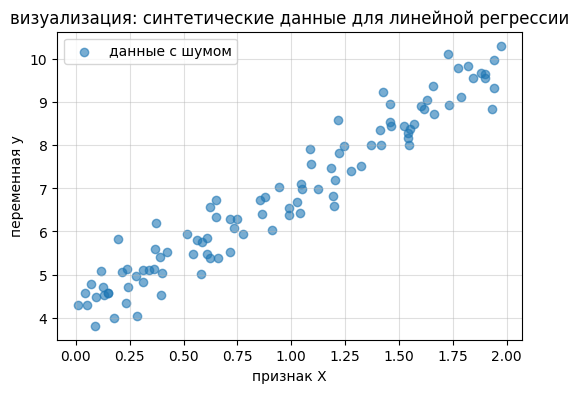

In [5]:
np.random.seed(42)
X = 2 * np.random.rand(100,1)
y_true = (4 +  3 * X + np.random.randn(100, 1) * 0.5).ravel()

plt.figure(figsize=(6,4))
plt.scatter(X, y_true, alpha=0.6, label = 'данные с шумом')
plt.xlabel('признак Х')
plt.ylabel('переменная у')
plt.title('визуализация: синтетические данные для линейной регрессии')
plt.grid(True, alpha = 0.4)
plt.legend()
plt.show()

In [11]:
model = LinearRegression(lr=0.01, n_iterations = 1000)
model.fit(X, y_true)


[итерация    0] Loss: 49.6385
[итерация  100] Loss: 0.3299
[итерация  200] Loss: 0.2612
[итерация  300] Loss: 0.2318
[итерация  400] Loss: 0.2169
[итерация  500] Loss: 0.2094
[итерация  600] Loss: 0.2056
[итерация  700] Loss: 0.2036
[итерация  800] Loss: 0.2027
[итерация  900] Loss: 0.2022


In [12]:
model.score(X, y_true)
yPred = model.predict(X)

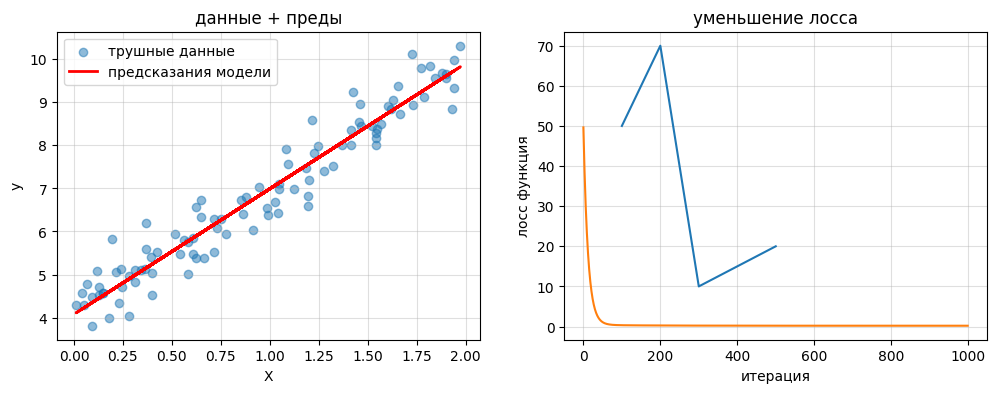

In [16]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.scatter(X, y_true, alpha = 0.5, label = 'трушные данные')
plt.plot(X, yPred, color = 'red', linewidth = 2, label = 'предсказания модели')
plt.xlabel('X')
plt.ylabel('y')
plt.title('данные + преды')
plt.legend()
plt.grid(True, alpha = 0.4)

plt.subplot(1, 2, 2)
plt.plot([100,200,300,500], [50,70,10,20])
plt.plot(model.loss_history)
plt.xlabel('итерация')
plt.ylabel('лосс функция')
plt.title('уменьшение лосса')
plt.grid(True, alpha = 0.4)

plt.show()